PRACTICAL CONTINUOUS ASSESSMENT 1

AutoClassify: An Intelligent Dataset-Aware Framework for Automatic Selection of Classification Algorithms

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import time

In [41]:
# ============================================================
# AUTOCLASSIFY
# Dataset-Aware Classification Algorithm Selection Framework
# Algorithms:
# 1. Decision Tree
# 2. Naive Bayes
# 3. Support Vector Machine
# ============================================================

import pandas as pd
import numpy as np
import time
import warnings

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_score
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [18]:
df=pd.read_csv("bank.csv", sep=";")

In [19]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [20]:
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df["y"].value_counts())


First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no



Dataset shape:
(4521, 17)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Target distribution:
y
no     4000
yes     521
Name: count, dtype: int64


1. Dataset Profiling

In [21]:
# ============================================================
# 3. DATASET PROFILER
# ============================================================

def dataset_profiler(data, target_column):

    X = data.drop(columns=[target_column])
    y = data[target_column]

    # Number of samples and features
    n_samples = X.shape[0]
    n_features = X.shape[1]

    # Feature types
    numerical_features = X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    binary_features = [
        col for col in X.columns
        if X[col].nunique(dropna=True) == 2
    ]

    # Target information
    n_classes = y.nunique()

    class_distribution = y.value_counts()

    # Imbalance ratio
    imbalance_ratio = (
        class_distribution.max() /
        class_distribution.min()
    )

    # Missing values
    total_missing = X.isnull().sum().sum()

    missing_percentage = (
        total_missing /
        (n_samples * n_features)
    ) * 100

    # Duplicate records
    duplicate_records = data.duplicated().sum()

    # Feature-to-sample ratio
    feature_sample_ratio = (
        n_features / n_samples
    )

    # Unique values
    unique_values = {
        col: X[col].nunique(dropna=True)
        for col in X.columns
    }

    profile = {
        "Number of Instances": n_samples,
        "Number of Features": n_features,
        "Numerical Features": len(numerical_features),
        "Categorical Features": len(categorical_features),
        "Binary Features": len(binary_features),
        "Number of Classes": n_classes,
        "Class Distribution": class_distribution.to_dict(),
        "Class Imbalance Ratio": imbalance_ratio,
        "Missing Value Percentage": missing_percentage,
        "Duplicate Records": duplicate_records,
        "Feature-to-Sample Ratio": feature_sample_ratio
    }

    return profile, numerical_features, categorical_features, binary_features

In [22]:
profile, numerical_features, categorical_features, binary_features = dataset_profiler(
    df,
    "y"
)

print("\n========== DATASET PROFILE ==========")

for key, value in profile.items():
    print(f"{key}: {value}")

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nBinary Features:")
print(binary_features)


========== DATASET PROFILE ==========
Number of Instances: 4521
Number of Features: 16
Numerical Features: 7
Categorical Features: 9
Binary Features: 3
Number of Classes: 2
Class Distribution: {'no': 4000, 'yes': 521}
Class Imbalance Ratio: 7.677543186180422
Missing Value Percentage: 0.0
Duplicate Records: 0
Feature-to-Sample Ratio: 0.0035390400353904005

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Binary Features:
['default', 'housing', 'loan']


In [23]:
# ============================================================
# 4. STATISTICAL ANALYSIS
# ============================================================

print("\n========== NUMERICAL STATISTICS ==========")

display(
    df[numerical_features].describe().T
)


========== NUMERICAL STATISTICS ==========


,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


In [24]:
print("\n========== CATEGORICAL STATISTICS ==========")

for col in categorical_features:

    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


========== CATEGORICAL STATISTICS ==========

job
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
Name: count, dtype: int64

marital
marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64

education
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64

default
default
no     4445
yes      76
Name: count, dtype: int64

housing
housing
yes    2559
no     1962
Name: count, dtype: int64

loan
loan
no     3830
yes     691
Name: count, dtype: int64

contact
contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64

month
month
may    1398
jul     706
aug     633
jun     531
nov     389
apr     293
feb     222
jan     148
oct      80
sep      52
Name: count, dtype: int64

poutcome
poutcome
unknown    3705
failure   

In [25]:
# ============================================================
# 5. MISSING VALUE ANALYSIS
# ============================================================

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    )
})

print("\n========== MISSING VALUE ANALYSIS ==========")

display(
    missing_table[
        missing_table["Missing Count"] > 0
    ]
)


========== MISSING VALUE ANALYSIS ==========


,Missing Count,Missing Percentage


In [27]:
# ============================================================
# 6. DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [28]:
# ============================================================
# 7. TARGET ANALYSIS
# ============================================================

print("\n========== TARGET ANALYSIS ==========")

print(df["y"].value_counts())

print("\nPercentage distribution:")

target_percentage = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
)

print(target_percentage)


========== TARGET ANALYSIS ==========
y
no     4000
yes     521
Name: count, dtype: int64

Percentage distribution:
y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64


In [29]:
# ============================================================
# 8. NUMERICAL CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df[
    numerical_features
].corr()

print("\n========== CORRELATION MATRIX ==========")

display(correlation_matrix)


========== CORRELATION MATRIX ==========


,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.083820,-0.017853,-0.002367,-0.005148,-0.008894,-0.003511
balance,0.083820,1.000000,-0.008677,-0.015950,-0.009976,0.009437,0.026196
day,-0.017853,-0.008677,1.000000,-0.024629,0.160706,-0.094352,-0.059114
duration,-0.002367,-0.015950,-0.024629,1.000000,-0.068382,0.010380,0.018080
campaign,-0.005148,-0.009976,0.160706,-0.068382,1.000000,-0.093137,-0.067833
pdays,-0.008894,0.009437,-0.094352,0.010380,-0.093137,1.000000,0.577562
previous,-0.003511,0.026196,-0.059114,0.018080,-0.067833,0.577562,1.000000


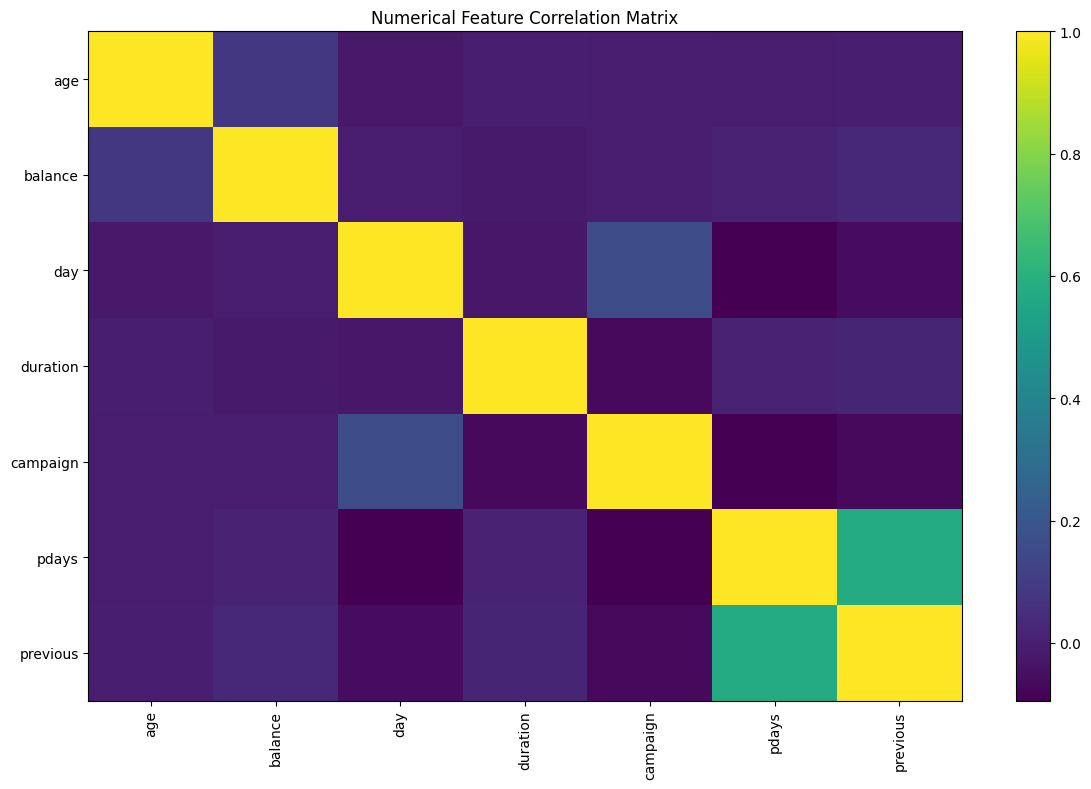

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar()

plt.title("Numerical Feature Correlation Matrix")

plt.tight_layout()

plt.show()

In [34]:
# ============================================================
# 9. DATA QUALITY ANALYZER
# ============================================================

def data_quality_analyzer(data, target_column):

    report = {}

    report["Total Rows"] = len(data)
    report["Total Columns"] = data.shape[1]

    report["Duplicate Rows"] = data.duplicated().sum()

    report["Total Missing Values"] = (
        data.isnull().sum().sum()
    )

    report["Target Missing Values"] = (
        data[target_column].isnull().sum()
    )

    report["Constant Features"] = [
        col for col in data.columns
        if col != target_column
        and data[col].nunique(dropna=True) <= 1
    ]

    return report

2. Automated preprocessing

Scaling required: Yes, because SVM is sensitive to differences in feature scale.
Decision Tree: Scaling not required.
Naïve Bayes: Scaling is not strictly required, but standardized features can be used consistently in the experimental pipeline.

In [35]:
# ============================================================
# 10. AUTOMATED DATA CLEANING
# ============================================================

data = df.copy()

# Remove duplicate rows
before = len(data)

data = data.drop_duplicates()

after = len(data)

print("Duplicate rows removed:", before - after)

# Remove rows where target is missing
data = data.dropna(
    subset=["y"]
)

print("Final dataset shape:", data.shape)

Duplicate rows removed: 0
Final dataset shape: (4521, 17)


In [36]:
# ============================================================
# 11. SEPARATE FEATURES AND TARGET
# ============================================================

X = data.drop(
    columns=["y"]
)

y = data["y"].map({
    "no": 0,
    "yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nEncoded target:")
print(y.value_counts())

X shape: (4521, 16)
y shape: (4521,)

Encoded target:
y
0    4000
1     521
Name: count, dtype: int64


In [37]:
# ============================================================
# 12. AUTOMATIC FEATURE TYPE DETECTION
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3616
Testing samples: 905


In [42]:
# ============================================================
# 14. PREPROCESSING PIPELINES
# ============================================================

numeric_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor_scaled = ColumnTransformer([
    (
        "numeric",
        numeric_preprocessor,
        numerical_features
    ),
    (
        "categorical",
        categorical_preprocessor,
        categorical_features
    )
])

In [43]:
numeric_preprocessor_tree = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

preprocessor_tree = ColumnTransformer([
    (
        "numeric",
        numeric_preprocessor_tree,
        numerical_features
    ),
    (
        "categorical",
        categorical_preprocessor,
        categorical_features
    )
])

3. Dataset-Aware Algorithm Suitability Engine

In [44]:
# ============================================================
# 15. CLASSIFIERS
# ============================================================

models = {

    "Decision Tree": Pipeline([
        (
            "preprocessing",
            preprocessor_tree
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]),

    "Naive Bayes": Pipeline([
        (
            "preprocessing",
            preprocessor_scaled
        ),
        (
            "classifier",
            GaussianNB()
        )
    ]),

    "SVM": Pipeline([
        (
            "preprocessing",
            preprocessor_scaled
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale"
            )
        )
    ])
}

print("Models created successfully.")

Models created successfully.


In [45]:
# ============================================================
# 16. DATASET-AWARE SUITABILITY ENGINE
# ============================================================

def calculate_suitability(profile, X):

    scores = {
        "Decision Tree": 0.0,
        "Naive Bayes": 0.0,
        "SVM": 0.0
    }

    reasons = {
        "Decision Tree": [],
        "Naive Bayes": [],
        "SVM": []
    }

    n_samples = profile["Number of Instances"]
    n_features = profile["Number of Features"]

    numerical_count = profile["Numerical Features"]
    categorical_count = profile["Categorical Features"]

    imbalance = profile["Class Imbalance Ratio"]

    missing = profile["Missing Value Percentage"]

    feature_sample_ratio = profile[
        "Feature-to-Sample Ratio"
    ]

    n_classes = profile["Number of Classes"]

    # --------------------------------------------------------
    # Dataset Size
    # --------------------------------------------------------

    if n_samples >= 10000:

        scores["Naive Bayes"] += 2.0

        reasons["Naive Bayes"].append(
            "The dataset contains a large number of observations, "
            "which favors the computational efficiency of Naive Bayes."
        )

        scores["Decision Tree"] += 1.0

    elif n_samples <= 3000:

        scores["SVM"] += 2.0

        reasons["SVM"].append(
            "The relatively smaller dataset makes SVM computationally feasible."
        )

    else:

        scores["SVM"] += 1.0
        scores["Decision Tree"] += 1.0

    # --------------------------------------------------------
    # Categorical Features
    # --------------------------------------------------------

    if categorical_count > 0:

        scores["Decision Tree"] += 2.0

        reasons["Decision Tree"].append(
            "The dataset contains categorical features, "
            "and Decision Trees can work naturally with encoded "
            "categorical information without requiring scaling."
        )

        scores["Naive Bayes"] += 1.0

        scores["SVM"] += 1.0

    # --------------------------------------------------------
    # Numerical Features
    # --------------------------------------------------------

    if numerical_count >= 10:

        scores["SVM"] += 1.5

        reasons["SVM"].append(
            "The dataset contains a relatively large numerical "
            "feature space where margin-based classification can be useful."
        )

    # --------------------------------------------------------
    # Number of Classes
    # --------------------------------------------------------

    if n_classes > 2:

        scores["Decision Tree"] += 1.0
        scores["SVM"] += 1.0

        reasons["Decision Tree"].append(
            "The multiclass structure can be handled naturally by Decision Trees."
        )

    else:

        scores["Naive Bayes"] += 1.0

        reasons["Naive Bayes"].append(
            "The binary classification structure is compatible with the efficient Naive Bayes classifier."
        )

    # --------------------------------------------------------
    # Class Imbalance
    # --------------------------------------------------------

    if imbalance >= 2:

        scores["Decision Tree"] += 1.0
        scores["SVM"] += 1.0

        reasons["Decision Tree"].append(
            "The dataset shows noticeable class imbalance."
        )

    else:

        scores["Naive Bayes"] += 1.0

    # --------------------------------------------------------
    # Feature-to-Sample Ratio
    # --------------------------------------------------------

    if feature_sample_ratio > 0.01:

        scores["SVM"] += 1.5

        reasons["SVM"].append(
            "The feature-to-sample ratio indicates a comparatively "
            "complex feature space."
        )

    else:

        scores["Naive Bayes"] += 1.0

    # --------------------------------------------------------
    # Missing Values
    # --------------------------------------------------------

    if missing > 0:

        scores["Decision Tree"] += 0.5

        reasons["Decision Tree"].append(
            "Missing values require preprocessing, while tree-based "
            "models are less sensitive to feature scaling."
        )

    # --------------------------------------------------------
    # Final ranking
    # --------------------------------------------------------

    ranking = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    predicted_algorithm = ranking[0][0]

    return scores, ranking, predicted_algorithm, reasons

In [46]:
# ============================================================
# 17. ANALYTICAL PREDICTION
# ============================================================

scores, ranking, predicted_algorithm, reasons = calculate_suitability(
    profile,
    X
)

print("\n========== SUITABILITY ANALYSIS ==========")

for algorithm, score in ranking:
    print(
        f"{algorithm}: {score:.2f}"
    )

print(
    "\nAnalytical Prediction:",
    predicted_algorithm
)


========== SUITABILITY ANALYSIS ==========
Decision Tree: 4.00
Naive Bayes: 3.00
SVM: 3.00

Analytical Prediction: Decision Tree


In [47]:
# ============================================================
# 18. EXPLAINABILITY
# ============================================================

print("\n========== EXPLANATION ==========")

print(
    f"\nAutoClassify analytically predicts: "
    f"{predicted_algorithm}"
)

print("\nReasons:")

for reason in reasons[predicted_algorithm]:

    print("•", reason)


========== EXPLANATION ==========

AutoClassify analytically predicts: Decision Tree

Reasons:
• The dataset contains categorical features, and Decision Trees can work naturally with encoded categorical information without requiring scaling.
• The dataset shows noticeable class imbalance.


In [48]:
# ============================================================
# 19. EXPERIMENTAL EVALUATION
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Training time
    start_train = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    train_time = (
        time.perf_counter() -
        start_train
    )

    # Prediction time
    start_prediction = time.perf_counter()

    y_pred = model.predict(
        X_test
    )

    prediction_time = (
        time.perf_counter() -
        start_prediction
    )

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": train_time,
        "Prediction Time": prediction_time
    })

    trained_models[name] = model

results_df = pd.DataFrame(results)

print("\n========== EXPERIMENTAL RESULTS ==========")

display(results_df)


Training Decision Tree...

Training Naive Bayes...

Training SVM...

========== EXPERIMENTAL RESULTS ==========


,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Decision Tree,0.857459,0.400000,0.480769,0.436681,0.112072,0.014987
1,Naive Bayes,0.820994,0.309211,0.451923,0.367188,0.038515,0.012290
2,SVM,0.893923,0.590909,0.250000,0.351351,0.518878,0.327646


In [49]:
# ============================================================
# 20. 5-FOLD CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    print(
        f"Running 5-fold CV for {name}..."
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1"
    )

    cv_results.append({
        "Algorithm": name,
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std": cv_scores.std()
    })

cv_df = pd.DataFrame(cv_results)

print("\n========== 5-FOLD CV RESULTS ==========")

display(cv_df)

Running 5-fold CV for Decision Tree...
Running 5-fold CV for Naive Bayes...
Running 5-fold CV for SVM...

========== 5-FOLD CV RESULTS ==========


,Algorithm,CV F1 Mean,CV F1 Std
0,Decision Tree,0.447083,0.037144
1,Naive Bayes,0.408857,0.037475
2,SVM,0.351464,0.060769


In [50]:
# ============================================================
# 21. COMBINE RESULTS
# ============================================================

final_results = results_df.merge(
    cv_df,
    on="Algorithm"
)

display(final_results)

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time,CV F1 Mean,CV F1 Std
0,Decision Tree,0.857459,0.400000,0.480769,0.436681,0.112072,0.014987,0.447083,0.037144
1,Naive Bayes,0.820994,0.309211,0.451923,0.367188,0.038515,0.012290,0.408857,0.037475
2,SVM,0.893923,0.590909,0.250000,0.351351,0.518878,0.327646,0.351464,0.060769


In [51]:
# ============================================================
# 22. EXPERIMENTAL EVALUATION SCORE
# ============================================================

final_results["Evaluation Score"] = (
    0.30 * final_results["F1 Score"] +
    0.20 * final_results["Precision"] +
    0.20 * final_results["Recall"] +
    0.30 * final_results["CV F1 Mean"]
)

print("\n========== FINAL EVALUATION SCORE ==========")

display(
    final_results.sort_values(
        "Evaluation Score",
        ascending=False
    )
)


========== FINAL EVALUATION SCORE ==========


,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time,CV F1 Mean,CV F1 Std,Evaluation Score
0,Decision Tree,0.857459,0.400000,0.480769,0.436681,0.112072,0.014987,0.447083,0.037144,0.441283
1,Naive Bayes,0.820994,0.309211,0.451923,0.367188,0.038515,0.012290,0.408857,0.037475,0.385040
2,SVM,0.893923,0.590909,0.250000,0.351351,0.518878,0.327646,0.351464,0.060769,0.379026


In [52]:
# ============================================================
# 23. EXPERIMENTAL WINNER
# ============================================================

experimental_winner = (
    final_results
    .sort_values(
        "Evaluation Score",
        ascending=False
    )
    .iloc[0]["Algorithm"]
)

print(
    "\nExperimental Winner:",
    experimental_winner
)


Experimental Winner: Decision Tree


In [53]:
# ============================================================
# 24. PREDICTION–REALITY ANALYSIS
# ============================================================

if predicted_algorithm == experimental_winner:

    prediction_status = "Confirmed"

else:

    prediction_status = "Not Confirmed"

print("\n========== PREDICTION STATUS ==========")

print(
    "Analytical Prediction:",
    predicted_algorithm
)

print(
    "Experimental Winner:",
    experimental_winner
)

print(
    "Prediction Status:",
    prediction_status
)


========== PREDICTION STATUS ==========
Analytical Prediction: Decision Tree
Experimental Winner: Decision Tree
Prediction Status: Confirmed


In [54]:
# ============================================================
# 25. FAILURE ANALYSIS
# ============================================================

if prediction_status == "Confirmed":

    failure_analysis = (
        f"The analytical prediction of {predicted_algorithm} "
        f"was confirmed by the experimental evaluation. "
        f"The dataset characteristics used by the suitability "
        f"engine were consistent with the observed model performance."
    )

else:

    failure_analysis = (
        f"AutoClassify predicted {predicted_algorithm}, but "
        f"{experimental_winner} achieved the highest overall "
        f"evaluation score. This indicates that the current "
        f"dataset-characteristic rules did not completely capture "
        f"the predictive structure of this dataset. Possible "
        f"causes include nonlinear feature interactions, the effect "
        f"of categorical encoding, class imbalance, or relationships "
        f"not represented by the current suitability criteria."
    )

print("\n========== FAILURE ANALYSIS ==========")

print(failure_analysis)


========== FAILURE ANALYSIS ==========
The analytical prediction of Decision Tree was confirmed by the experimental evaluation. The dataset characteristics used by the suitability engine were consistent with the observed model performance.


In [56]:
# ============================================================
# 26. CONFUSION MATRICES
# ============================================================

for name, model in trained_models.items():

    y_pred = model.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(
        f"\n{name} Confusion Matrix:"
    )

    print(cm)


Decision Tree Confusion Matrix:
[[726  75]
 [ 54  50]]

Naive Bayes Confusion Matrix:
[[696 105]
 [ 57  47]]

SVM Confusion Matrix:
[[783  18]
 [ 78  26]]


In [57]:
# ============================================================
# 27. CLASSIFICATION REPORTS
# ============================================================

for name, model in trained_models.items():

    y_pred = model.predict(
        X_test
    )

    print(
        f"\n========== {name} =========="
    )

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No", "Yes"],
            zero_division=0
        )
    )


========== Decision Tree ==========
              precision    recall  f1-score   support

          No       0.93      0.91      0.92       801
         Yes       0.40      0.48      0.44       104

    accuracy                           0.86       905
   macro avg       0.67      0.69      0.68       905
weighted avg       0.87      0.86      0.86       905


========== Naive Bayes ==========
              precision    recall  f1-score   support

          No       0.92      0.87      0.90       801
         Yes       0.31      0.45      0.37       104

    accuracy                           0.82       905
   macro avg       0.62      0.66      0.63       905
weighted avg       0.85      0.82      0.84       905


========== SVM ==========
              precision    recall  f1-score   support

          No       0.91      0.98      0.94       801
         Yes       0.59      0.25      0.35       104

    accuracy                           0.89       905
   macro avg       0.75      

In [58]:
# ============================================================
# 28. SVM HYPERPARAMETER EXPERIMENT
# ============================================================

svm_results = []

C_values = [
    0.1,
    1,
    10
]

gamma_values = [
    "scale",
    0.01,
    0.1
]

# ------------------------------------------------------------
# Linear SVM
# ------------------------------------------------------------

for C in C_values:

    linear_svm = Pipeline([

        (
            "preprocessing",
            preprocessor_scaled
        ),

        (
            "classifier",
            SVC(
                kernel="linear",
                C=C
            )
        )
    ])

    scores = cross_val_score(
        linear_svm,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    svm_results.append({
        "Kernel": "Linear",
        "C": C,
        "Gamma": "Not Applicable",
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })


# ------------------------------------------------------------
# RBF SVM
# ------------------------------------------------------------

for C in C_values:

    for gamma in gamma_values:

        rbf_svm = Pipeline([

            (
                "preprocessing",
                preprocessor_scaled
            ),

            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=C,
                    gamma=gamma
                )
            )
        ])

        scores = cross_val_score(
            rbf_svm,
            X_train,
            y_train,
            cv=5,
            scoring="f1"
        )

        svm_results.append({
            "Kernel": "RBF",
            "C": C,
            "Gamma": gamma,
            "Mean CV F1": scores.mean(),
            "Std CV F1": scores.std()
        })

svm_results_df = pd.DataFrame(
    svm_results
)

print(
    "\n========== SVM HYPERPARAMETER RESULTS =========="
)

display(
    svm_results_df.sort_values(
        "Mean CV F1",
        ascending=False
    )
)


========== SVM HYPERPARAMETER RESULTS ==========


,Kernel,C,Gamma,Mean CV F1,Std CV F1
11,RBF,10.0,0.1,0.500291,0.047308
9,RBF,10.0,scale,0.488717,0.057425
10,RBF,10.0,0.01,0.372887,0.037490
8,RBF,1.0,0.1,0.363247,0.052350
6,RBF,1.0,scale,0.360820,0.061264
2,Linear,10.0,Not Applicable,0.345381,0.035302
1,Linear,1.0,Not Applicable,0.320195,0.041684
0,Linear,0.1,Not Applicable,0.288795,0.046651
7,RBF,1.0,0.01,0.059212,0.022601
3,RBF,0.1,scale,0.000000,0.000000


In [59]:
# ============================================================
# 29. BEST SVM CONFIGURATION
# ============================================================

best_svm = (
    svm_results_df
    .sort_values(
        "Mean CV F1",
        ascending=False
    )
    .iloc[0]
)

print("\n========== BEST SVM CONFIGURATION ==========")

print("Kernel:", best_svm["Kernel"])
print("C:", best_svm["C"])
print("Gamma:", best_svm["Gamma"])
print(
    "Mean CV F1:",
    round(best_svm["Mean CV F1"], 4)
)


========== BEST SVM CONFIGURATION ==========
Kernel: RBF
C: 10.0
Gamma: 0.1
Mean CV F1: 0.5003


In [60]:
# ============================================================
# 30. COMPUTATIONAL COMPARISON
# ============================================================

computational_table = final_results[
    [
        "Algorithm",
        "Training Time",
        "Prediction Time"
    ]
].copy()

print("\n========== COMPUTATIONAL COMPARISON ==========")

display(computational_table)


========== COMPUTATIONAL COMPARISON ==========


,Algorithm,Training Time,Prediction Time
0,Decision Tree,0.112072,0.014987
1,Naive Bayes,0.038515,0.012290
2,SVM,0.518878,0.327646


In [61]:
# ============================================================
# 31. FINAL AUTOCLASSIFY REPORT
# ============================================================

print("\n")
print("=" * 70)
print("                 AUTOCLASSIFY FINAL REPORT")
print("=" * 70)

print("\nDATASET PROFILE")
print("-" * 70)

for key, value in profile.items():
    print(f"{key}: {value}")

print("\nPREPROCESSING")
print("-" * 70)

print("• Missing numerical values → Median imputation")
print("• Missing categorical values → Most-frequent imputation")
print("• Categorical variables → One-hot encoding")
print("• Numerical variables → Standardization for SVM/NB")
print("• Decision Tree → No feature scaling")
print("• Duplicate records → Automatically removed")

print("\nSUITABILITY ANALYSIS")
print("-" * 70)

for algorithm, score in ranking:

    print(
        f"{algorithm}: {score:.2f}"
    )

print("\nANALYTICAL PREDICTION")
print("-" * 70)

print(predicted_algorithm)

print("\nEXPERIMENTAL RESULTS")
print("-" * 70)

display(final_results)

print("\nEXPERIMENTAL WINNER")
print("-" * 70)

print(experimental_winner)

print("\nPREDICTION STATUS")
print("-" * 70)

print(prediction_status)

print("\nEXPLANATION")
print("-" * 70)

for reason in reasons[predicted_algorithm]:

    print("•", reason)

print("\nFAILURE / PREDICTION-REALITY ANALYSIS")
print("-" * 70)

print(failure_analysis)

print("\n")
print("=" * 70)
print("                    END OF REPORT")
print("=" * 70)



                 AUTOCLASSIFY FINAL REPORT

DATASET PROFILE
----------------------------------------------------------------------
Number of Instances: 4521
Number of Features: 16
Numerical Features: 7
Categorical Features: 9
Binary Features: 3
Number of Classes: 2
Class Distribution: {'no': 4000, 'yes': 521}
Class Imbalance Ratio: 7.677543186180422
Missing Value Percentage: 0.0
Duplicate Records: 0
Feature-to-Sample Ratio: 0.0035390400353904005

PREPROCESSING
----------------------------------------------------------------------
• Missing numerical values → Median imputation
• Missing categorical values → Most-frequent imputation
• Categorical variables → One-hot encoding
• Numerical variables → Standardization for SVM/NB
• Decision Tree → No feature scaling
• Duplicate records → Automatically removed

SUITABILITY ANALYSIS
----------------------------------------------------------------------
Decision Tree: 4.00
Naive Bayes: 3.00
SVM: 3.00

ANALYTICAL PREDICTION
--------------------

,Algorithm,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time,CV F1 Mean,CV F1 Std,Evaluation Score
0,Decision Tree,0.857459,0.400000,0.480769,0.436681,0.112072,0.014987,0.447083,0.037144,0.441283
1,Naive Bayes,0.820994,0.309211,0.451923,0.367188,0.038515,0.012290,0.408857,0.037475,0.385040
2,SVM,0.893923,0.590909,0.250000,0.351351,0.518878,0.327646,0.351464,0.060769,0.379026



EXPERIMENTAL WINNER
----------------------------------------------------------------------
Decision Tree

PREDICTION STATUS
----------------------------------------------------------------------
Confirmed

EXPLANATION
----------------------------------------------------------------------
• The dataset contains categorical features, and Decision Trees can work naturally with encoded categorical information without requiring scaling.
• The dataset shows noticeable class imbalance.

FAILURE / PREDICTION-REALITY ANALYSIS
----------------------------------------------------------------------
The analytical prediction of Decision Tree was confirmed by the experimental evaluation. The dataset characteristics used by the suitability engine were consistent with the observed model performance.


                    END OF REPORT


In [64]:
import pickle
import os

# Create the models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained models
with open("models/decision_tree.pkl", "wb") as f:
    pickle.dump(trained_models["Decision Tree"], f)

with open("models/naive_bayes.pkl", "wb") as f:
    pickle.dump(trained_models["Naive Bayes"], f)

with open("models/svm.pkl", "wb") as f:
    pickle.dump(trained_models["SVM"], f)

# Load the models
with open("models/decision_tree.pkl", "rb") as f:
    dt_model = pickle.load(f)

with open("models/naive_bayes.pkl", "rb") as f:
    nb_model = pickle.load(f)

with open("models/svm.pkl", "rb") as f:
    svm_model = pickle.load(f)

print("Models loaded successfully.")

Models loaded successfully.
